In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/ML/cpu/cleaned_log.csv")
df.head()



,Timestamp,temp_cpu,util_total,util_core_avg,active_cores,clk_eff_avg,clk_eff_avg_alt,power_pkg,power_core,power_soc,current_core,current_tdc,current_edc,mem_load,mem_used,dram_read_bw,dram_write_bw,fan_rpm,thermal_limit
0,2026-02-05 19:05:46.351,92.8,61.7,61.7,5.8,2594.2,2594.2,54.062,46.910,2.993,37.219,37.434,104.552,60.8,9491,0.979,0.218,2700,99.8
1,2026-02-05 19:05:46.864,93.0,68.7,68.7,6.6,2995.6,2995.6,59.108,51.963,3.050,41.227,40.006,108.899,60.8,9493,2.270,0.355,2700,99.9
2,2026-02-05 19:05:47.366,93.1,62.8,62.8,6.0,2712.9,2712.9,56.307,49.243,3.012,38.931,39.922,107.690,60.8,9501,1.373,0.274,2700,99.9
3,2026-02-05 19:05:47.868,93.1,61.8,61.8,5.6,2560.0,2560.0,52.696,45.690,2.976,36.375,36.878,102.598,60.8,9495,1.131,0.221,2800,100.0
4,2026-02-05 19:05:48.386,93.2,60.9,60.9,5.7,2682.0,2682.0,55.775,48.727,3.008,38.286,37.430,109.197,60.8,9497,1.109,0.256,2700,99.8


In [ ]:
df.columns

Index(['Timestamp', 'temp_cpu', 'util_total', 'util_core_avg', 'active_cores',
       'clk_eff_avg', 'clk_eff_avg_alt', 'power_pkg', 'power_core',
       'power_soc', 'current_core', 'current_tdc', 'current_edc', 'mem_load',
       'mem_used', 'dram_read_bw', 'dram_write_bw', 'fan_rpm',
       'thermal_limit'],
      dtype='object')

delta

In [ ]:
# ==========================================
# ULTIMATE MASTER CELL: MULTI-FEATURE DELTA
# ==========================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

HORIZON = 10      # 10s ahead
WINDOW_SIZE = 40  # 20s history

df_model = df.copy()

# 1. FEATURE SELECTION (Using Leading Indicators)
# We use Usage and Power to "see" the future heat
feature_cols = ['temp_cpu', 'util_total', 'power_pkg', 'current_core','fan_rpm','clk_eff_avg']

# 2. DELTA TARGET
# We still predict the "Change" to keep the model aggressive
df_model["delta_target"] = df_model["temp_cpu"].shift(-HORIZON) - df_model["temp_cpu"]

df_model = df_model.dropna().reset_index(drop=True)

# Add this right before Section 4 (Scaling)
df_model['power_pkg'] *= 2.0  # Amplify the "Heat" signal
df_model['util_total'] *= 1.5 # Amplify the "Work" signal

# Extract feature values for 3D array creation
data_values = df_model[feature_cols].values # Corrected line

# 3. GENERATE WINDOWS (Corrected Alignment)
X_3D, y_list, current_temp_list = [], [], []

# We iterate up to len - HORIZON because delta_target is already shifted
for i in range(WINDOW_SIZE, len(df_model) - HORIZON):
    # Features: The window of data ending RIGHT NOW (at index i)
    X_3D.append(data_values[i-WINDOW_SIZE:i])

    # Target: Use the delta_target AT index i.
    # Since delta_target = temp[i+HORIZON] - temp[i],
    # the model learns to associate current power with that future jump.
    y_list.append(df_model["delta_target"].iloc[i])

    # Use the temp at index i to reconstruct the prediction later
    current_temp_list.append(df_model['temp_cpu'].iloc[i])

X_3D = np.array(X_3D)
y_delta = np.array(y_list).reshape(-1, 1)
current_temps = np.array(current_temp_list).reshape(-1, 1)

# 4. SPLIT & SCALE
split = int(len(y_delta) * 0.8)
X_train_3D_raw, X_test_3D_raw = X_3D[:split], X_3D[split:]
y_train_delta_raw, y_test_delta_raw = y_delta[:split], y_delta[split:]
test_current_temps = current_temps[split:]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Scale 3D based on the new 4 features
n_features = len(feature_cols)
X_train_3D = scaler_X.fit_transform(X_train_3D_raw.reshape(-1, n_features)).reshape(X_train_3D_raw.shape)
X_test_3D = scaler_X.transform(X_test_3D_raw.reshape(-1, n_features)).reshape(X_test_3D_raw.shape)

y_train = scaler_y.fit_transform(y_train_delta_raw)
y_test = scaler_y.transform(y_test_delta_raw)

print(f"✅ Ready! Using {n_features} features to kill the lag.")

✅ Ready! Using 6 features to kill the lag.


In [ ]:
# =====================================
# HYBRID CNN-LSTM (DELTA VERSION)
# =====================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

# 1. Build Model (Architecture remains the same, but it learns Deltas now)
model_delta = Sequential([
    Input(shape=(X_train_3D.shape[1], X_train_3D.shape[2])),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1) # Predicts the 'Change' value
])

model_delta.compile(optimizer='adam', loss='mae')

# 2. Train on Delta Targets
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

model_delta.fit(X_train_3D, y_train, epochs=20, batch_size=32,
                validation_data=(X_test_3D, y_test), callbacks=[early_stop], verbose=1)

# 3. Predict the Delta
y_pred_delta_scaled = model_delta.predict(X_test_3D)
y_pred_delta = scaler_y.inverse_transform(y_pred_delta_scaled)

# 4. RECONSTRUCTION (The Fix for the Lag)
# We add the predicted CHANGE to the CURRENT temperature to get the FUTURE forecast
y_final_forecast = test_current_temps + y_pred_delta
y_actual_future = test_current_temps + y_test_delta_raw # Reconstruct actuals for plotting

# 5. Evaluate and Plot
from sklearn.metrics import r2_score, mean_absolute_error
r2 = r2_score(y_actual_future, y_final_forecast)
mae = mean_absolute_error(y_actual_future, y_final_forecast)

print(f"\n--- Delta Hybrid Results ---")
print(f"R2: {r2:.4f} | MAE: {mae:.4f}")

plt.figure(figsize=(12, 5))
plt.plot(y_actual_future[:400], label="Actual Future Temp", color="black", alpha=0.5)
plt.plot(y_final_forecast[:400], label="Delta-Based Prediction", color="red", linewidth=2)
plt.title(f"Hybrid Model with Delta Logic (Horizon: {HORIZON*0.5}s)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

KeyboardInterrupt: 

In [ ]:
from sklearn.svm import SVR

model_svr = SVR(kernel='rbf', C=10, epsilon=0.01)
model_svr.fit(X_train_2D, y_train.ravel())

y_pred_svr = scaler_y.inverse_transform(model_svr.predict(X_test_2D).reshape(-1,1))

print(f"--- SVR Results ---")
print(f"R2: {r2_score(y_actual, y_pred_svr):.4f}")
print(f"MAE: {mean_absolute_error(y_actual, y_pred_svr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_actual, y_pred_svr)):.4f}")

plt.figure(figsize=(10,4))
plt.plot(y_actual[:300], label="Actual", color="black", alpha=0.7)
plt.plot(y_pred_svr[:300], label="SVR Prediction", color="red", linestyle="--")
plt.title("SVR: Actual vs Predicted")
plt.legend(); plt.show()

NameError: name 'X_train_2D' is not defined

# **RANDOM FOREST**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# --- 1. Feature Engineering ---
df_rf = df.copy()

# HORIZON of 20 = 10 seconds ahead
HORIZON = 20

# Create 'Velocity' features (Rate of change)
df_rf['power_vel'] = df_rf['power_pkg'].diff().fillna(0)
df_rf['util_vel'] = df_rf['util_total'].diff().fillna(0)

# Target: The change in temperature that will happen 10s from now
df_rf['delta_target'] = df_rf['temp_cpu'].shift(-HORIZON) - df_rf['temp_cpu']

# Drop rows where we don't have a future target
df_rf = df_rf.dropna().reset_index(drop=True)

# Select features that lead the thermal response
feature_cols = ['temp_cpu', 'power_pkg', 'power_vel', 'util_total', 'util_vel', 'fan_rpm']

X = df_rf[feature_cols].values
y = df_rf['delta_target'].values
current_temps = df_rf['temp_cpu'].values

In [ ]:
# --- 2. Split and Train ---
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
test_current_temps = current_temps[split:]

# Instantiate and fit
# max_depth=10 prevents the trees from overfitting to noise
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# --- 3. Prediction & Reconstruction ---
y_pred_delta = rf_model.predict(X_test)
# The final prediction is: Current Temp + Predicted Change
final_predictions = test_current_temps + y_pred_delta

# Ground Truth for comparison (what actually happened 10s later)
actual_future = test_current_temps + y_test
rf_r2 = r2_score(actual_future, final_predictions)
rf_mae = mean_absolute_error(actual_future, final_predictions)
rf_rmse = np.sqrt(mean_squared_error(actual_future, final_predictions))

print(f"--- Random Forest Metrics ---")
print(f"R2 Score: {rf_r2:.4f}")
print(f"MAE:      {rf_mae:.4f} °C")
print(f"RMSE:     {rf_rmse:.4f} °C")

--- Random Forest Metrics ---
R2 Score: 0.9496
MAE:      1.4491 °C
RMSE:     3.6431 °C


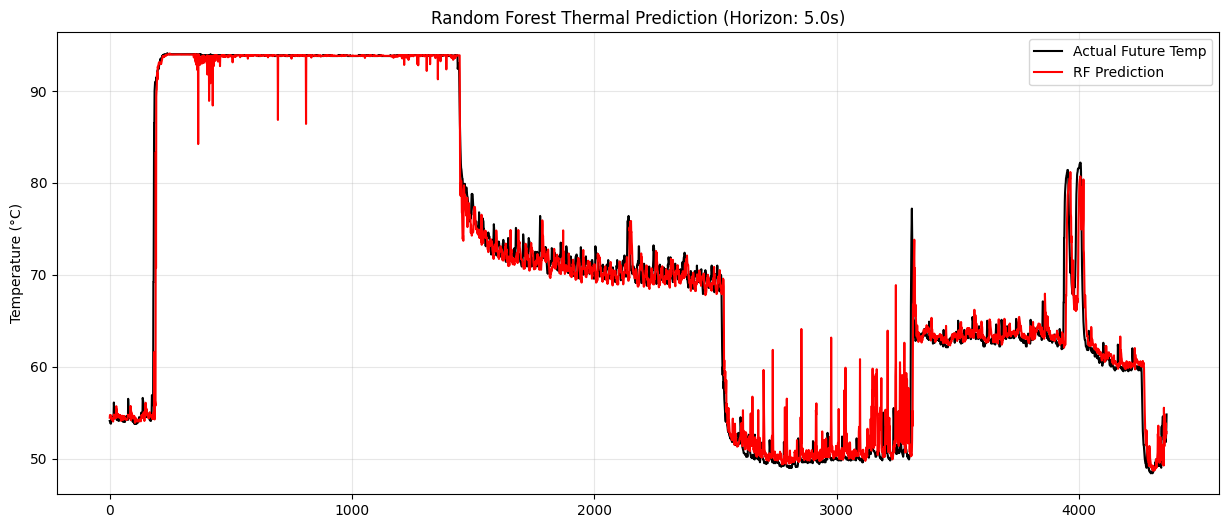

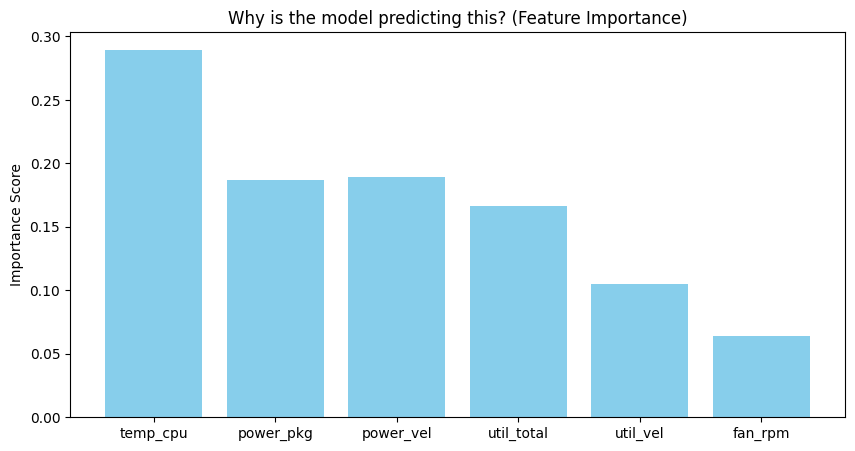

In [ ]:
# --- 4. Plotting Results ---
plt.figure(figsize=(15, 6))
plt.plot(actual_future, label='Actual Future Temp', color='black')
plt.plot(final_predictions, label='RF Prediction', color='red', linewidth=1.5)
plt.title(f"Random Forest Thermal Prediction (Horizon: {HORIZON/2}s)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- 5. Feature Importance (Academic Bonus) ---
importances = rf_model.feature_importances_
plt.figure(figsize=(10, 5))
plt.bar(feature_cols, importances, color='skyblue')
plt.title("Why is the model predicting this? (Feature Importance)")
plt.ylabel("Importance Score")
plt.show()

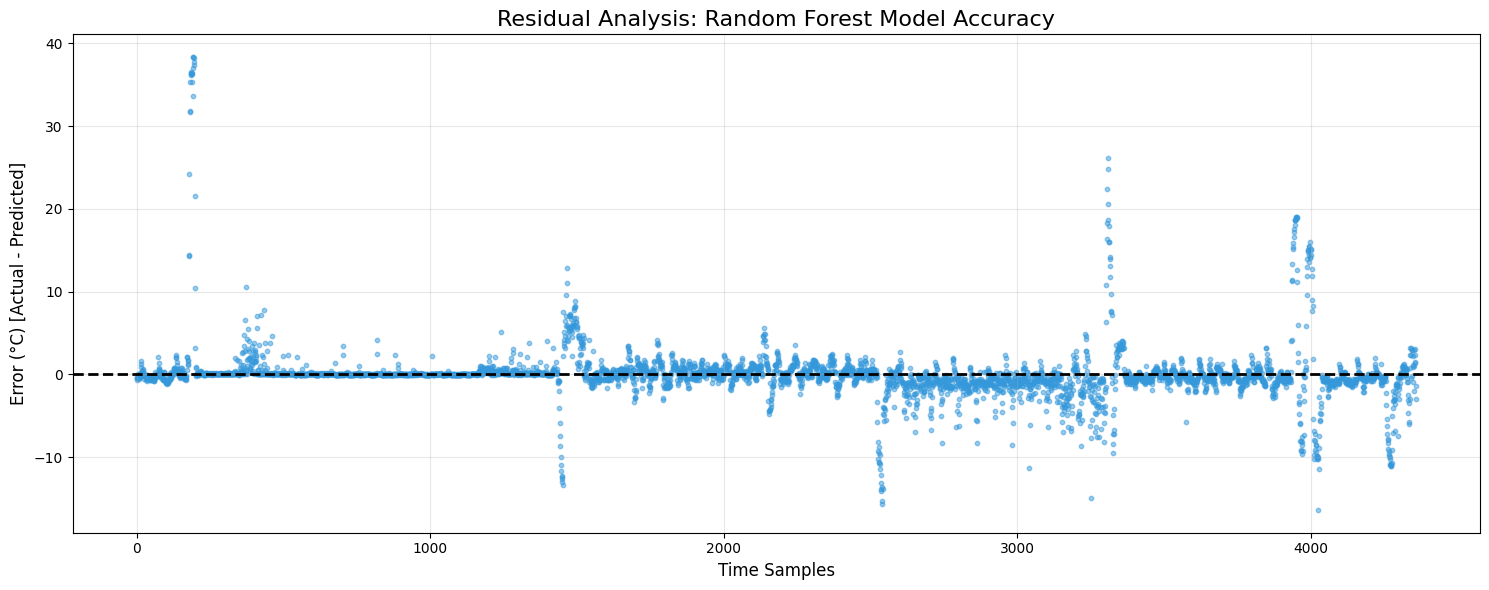

In [ ]:
import matplotlib.pyplot as plt

# Calculate Residuals (Actual - Predicted)
residuals_rf = actual_future - final_predictions

plt.figure(figsize=(15, 6))

# Plotting the residuals
plt.scatter(range(len(residuals_rf)), residuals_rf, alpha=0.5, s=10, color='#3498db')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)

plt.title("Residual Analysis: Random Forest Model Accuracy", fontsize=16)
plt.xlabel("Time Samples", fontsize=12)
plt.ylabel("Error (°C) [Actual - Predicted]", fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **XGBOOST**

In [ ]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

# --- 1. Prepare Data (Reusing your RF features) ---
# Ensure you have 'power_vel' and 'util_vel' from the previous step
X = df_rf[feature_cols].values
y = df_rf['delta_target'].values

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
test_current_temps = df_rf['temp_cpu'].values[split:]

# --- 2. Train XGBoost ---
# learning_rate: helps prevent overfitting
# n_estimators: number of boosting rounds
# max_depth: usually kept low (3-6) for boosting
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# --- 3. Predict & Reconstruct ---
y_pred_delta = xgb_model.predict(X_test)
final_predictions_xgb = test_current_temps + y_pred_delta
actual_future = test_current_temps + y_test
# Metrics
xgb_r2 = r2_score(actual_future, final_predictions_xgb)
xgb_mae = mean_absolute_error(actual_future, final_predictions_xgb)
xgb_rmse = np.sqrt(mean_squared_error(actual_future, final_predictions_xgb))

print(f"--- XGBoost Metrics ---")
print(f"R2 Score: {xgb_r2:.4f}")
print(f"MAE:      {xgb_mae:.4f} °C")
print(f"RMSE:     {xgb_rmse:.4f} °C")

--- XGBoost Metrics ---
R2 Score: 0.9511
MAE:      1.4875 °C
RMSE:     3.5913 °C


In [ ]:
# Calculate absolute error for each point
errors = np.abs(actual_future - final_predictions_lr)
# Count how many points have an error greater than 20 degrees
outliers_count = np.sum(errors > 15)
# Calculate the percentage of total test points
percent_outliers = (outliers_count / len(errors)) * 100
print(f"Number of points with >15°C error: {outliers_count}")
print(f"Percentage of total data: {percent_outliers:.2f}%")

Number of points with >15°C error: 51
Percentage of total data: 1.17%


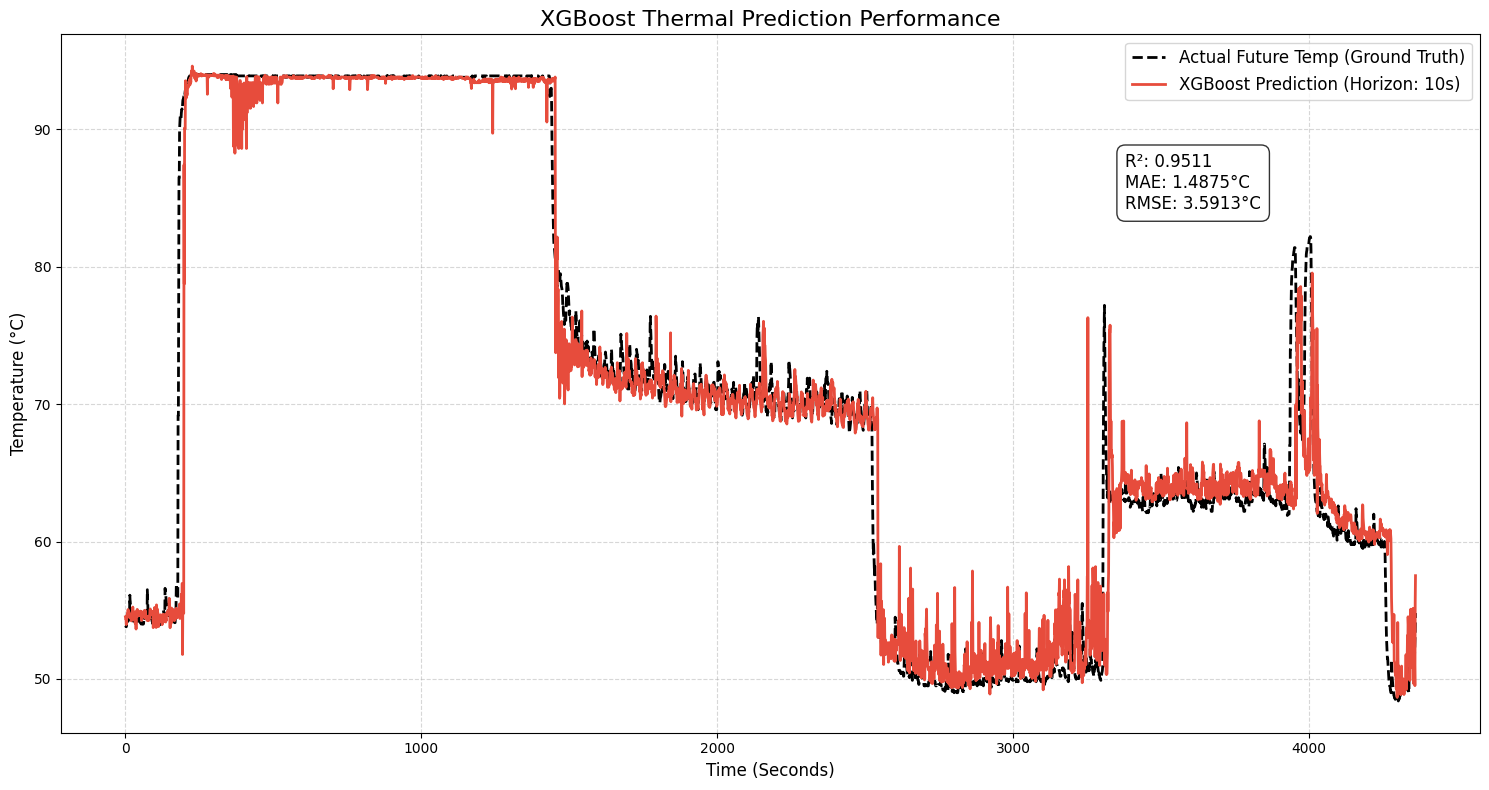

In [ ]:
import matplotlib.pyplot as plt

# --- 1. Generate the Plot ---
plt.figure(figsize=(15, 8))

# Main Temperature Plot
plt.plot(actual_future, label='Actual Future Temp (Ground Truth)', color='black', linewidth=2, linestyle='--')
plt.plot(final_predictions_xgb, label='XGBoost Prediction (Horizon: 10s)', color='#e74c3c', linewidth=2)

# Styling
plt.title("XGBoost Thermal Prediction Performance", fontsize=16)
plt.xlabel("Time (Seconds)", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Highlight the Metrics on the Plot (Academic Style)
stats_text = f'R²: {xgb_r2:.4f}\nMAE: {xgb_mae:.4f}°C\nRMSE: {xgb_rmse:.4f}°C'
plt.gca().annotate(stats_text, xy=(0.75, 0.75), xycoords='axes fraction',
            bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.8),
            fontsize=12)

plt.tight_layout()
plt.show()

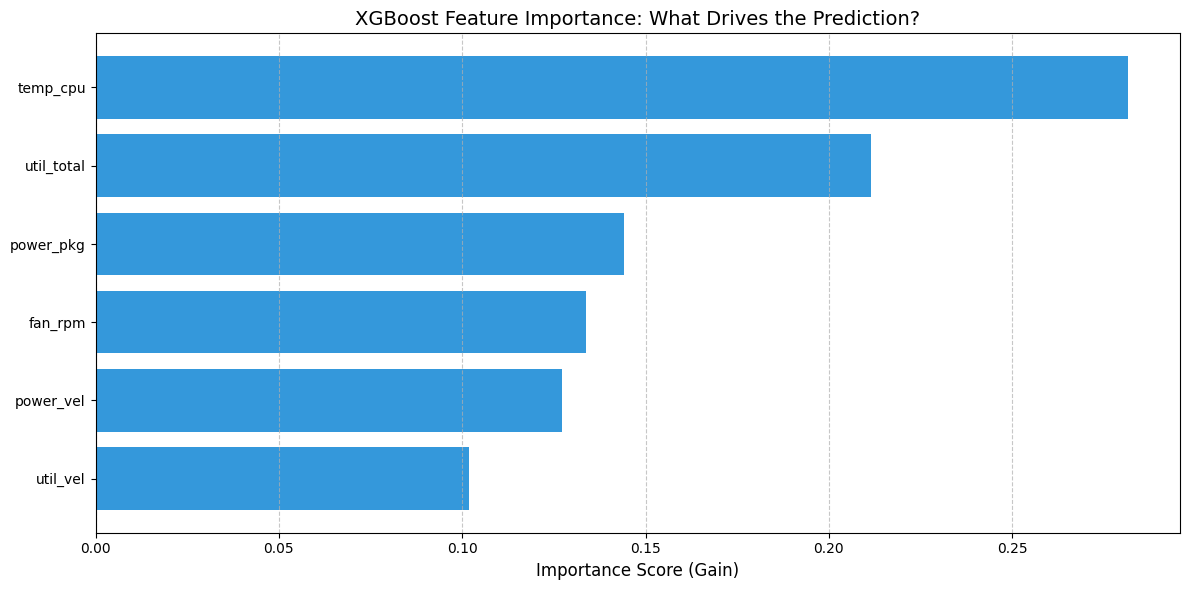

In [ ]:
import matplotlib.pyplot as plt

# Get feature importance scores from the XGBoost model
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [feature_cols[i] for i in indices]

# Create the plot
plt.figure(figsize=(12, 6))
plt.barh(range(len(indices)), importances[indices], color='#3498db', align='center')
plt.yticks(range(len(indices)), sorted_features)
plt.gca().invert_yaxis()  # Put the most important at the top

plt.title("XGBoost Feature Importance: What Drives the Prediction?", fontsize=14)
plt.xlabel("Importance Score (Gain)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

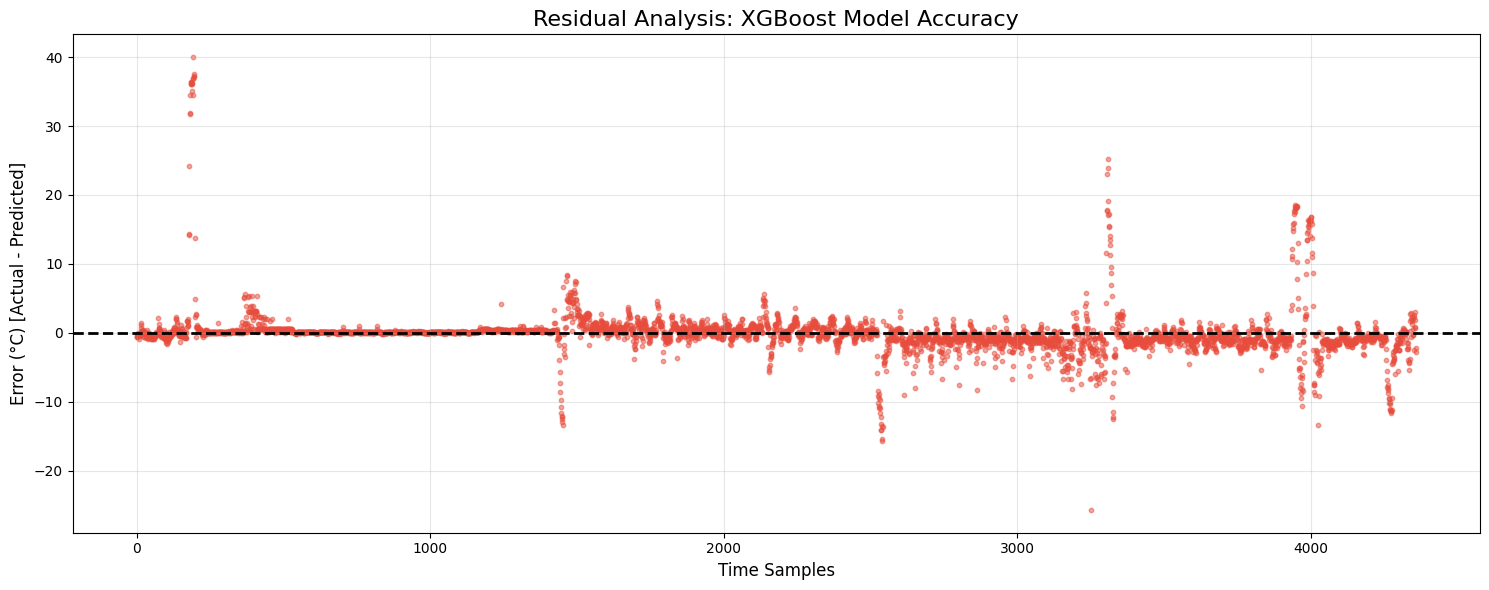

In [ ]:
import matplotlib.pyplot as plt

# Calculate Residuals (Actual - Predicted)
residuals_xgb = actual_future - final_predictions_xgb

plt.figure(figsize=(15, 6))

# Plotting the residuals
plt.scatter(range(len(residuals_xgb)), residuals_xgb, alpha=0.5, s=10, color='#e74c3c')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)

plt.title("Residual Analysis: XGBoost Model Accuracy", fontsize=16)
plt.xlabel("Time Samples", fontsize=12)
plt.ylabel("Error (°C) [Actual - Predicted]", fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Random forest vs xgboost**

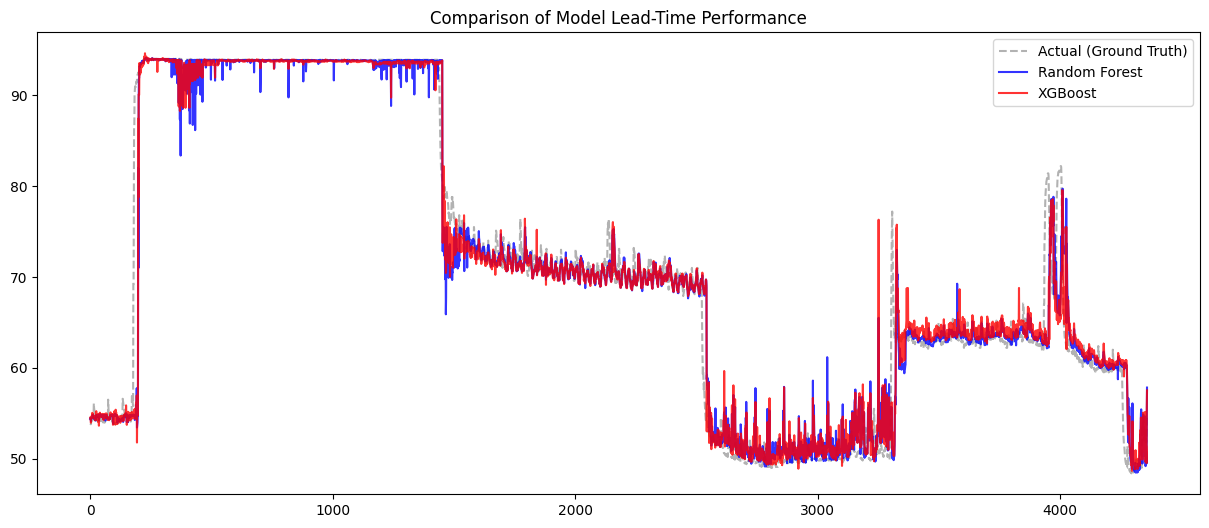

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(actual_future, label='Actual (Ground Truth)', color='black', alpha=0.3, linestyle='--')
plt.plot(final_predictions, label='Random Forest', color='blue', alpha=0.8)
plt.plot(final_predictions_xgb, label='XGBoost', color='red', alpha=0.8)
plt.title("Comparison of Model Lead-Time Performance")
plt.legend()
plt.show()

# **LIGHT GBM**

In [ ]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# --- 1. Prepare Data ---
# We use the same features and delta target as your XGBoost script
X = df_rf[feature_cols].values
y = df_rf['delta_target'].values

# Chronological Split (80/20)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Store current temperatures to reconstruct final °C later
test_current_temps = df_rf['temp_cpu'].values[split:]

# --- 2. Train LightGBM ---
# learning_rate: Controls the impact of each tree
# num_leaves: Main parameter to control model complexity (LightGBM is leaf-wise)
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1  # Suppresses unnecessary output
)

lgb_model.fit(X_train, y_train)

# --- 3. Predict & Reconstruct (Delta Logic) ---
# Step A: Predict the change (delta)
y_pred_delta_lgb = lgb_model.predict(X_test)

# Step B: Add the delta to current temp to get final °C
final_predictions_lgb = test_current_temps + y_pred_delta_lgb

# Step C: Create actual future values for comparison
actual_future = test_current_temps + y_test

# --- 4. Metrics ---
lgb_r2 = r2_score(actual_future, final_predictions_lgb)
lgb_mae = mean_absolute_error(actual_future, final_predictions_lgb)
lgb_rmse = np.sqrt(mean_squared_error(actual_future, final_predictions_lgb))

print(f"--- LightGBM Metrics ---")
print(f"R2 Score: {lgb_r2:.4f}")
print(f"MAE:      {lgb_mae:.4f} °C")
print(f"RMSE:     {lgb_rmse:.4f} °C")

--- LightGBM Metrics ---
R2 Score: 0.9504
MAE:      1.5043 °C
RMSE:     3.6170 °C


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


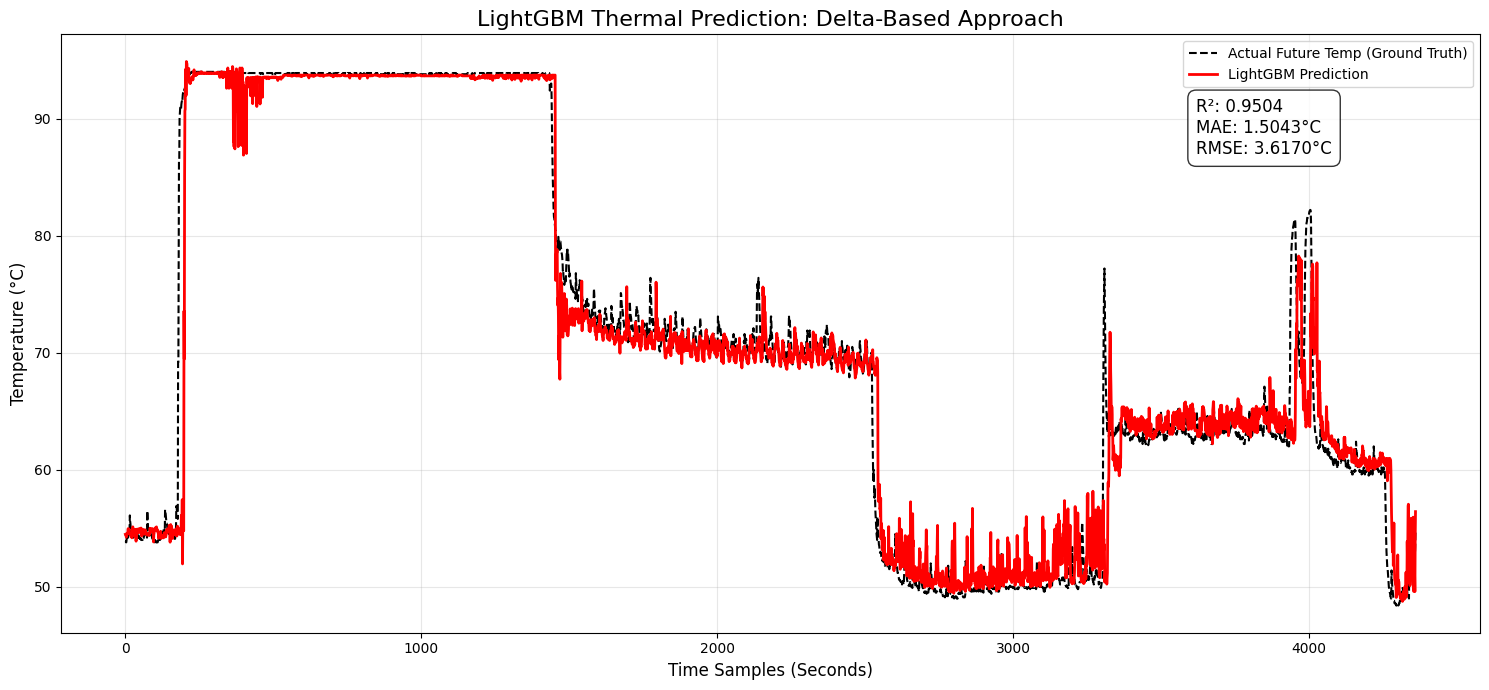

In [ ]:
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# --- 1. Prepare Data ---
# We use the same features and delta target as your XGBoost script
X = df_rf[feature_cols].values
y = df_rf['delta_target'].values

# Chronological Split (80/20)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Store current temperatures to reconstruct final °C later
test_current_temps = df_rf['temp_cpu'].values[split:]

# --- 2. Train LightGBM ---
# learning_rate: Controls the impact of each tree
# num_leaves: Main parameter to control model complexity (LightGBM is leaf-wise)
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1  # Suppresses unnecessary output
)

lgb_model.fit(X_train, y_train)

# --- 3. Predict & Reconstruct (Delta Logic) ---
# Step A: Predict the change (delta)
y_pred_delta_lgb = lgb_model.predict(X_test)

# Step B: Add the delta to current temp to get final °C
final_predictions_lgb = test_current_temps + y_pred_delta_lgb

# Step C: Create actual future values for comparison
actual_future = test_current_temps + y_test

# --- 4. Metrics ---
lgb_r2 = r2_score(actual_future, final_predictions_lgb)
lgb_mae = mean_absolute_error(actual_future, final_predictions_lgb)
lgb_rmse = np.sqrt(mean_squared_error(actual_future, final_predictions_lgb))

# --- Generate the LightGBM Plot ---
plt.figure(figsize=(15, 7))

# Plot Actual vs Predicted
plt.plot(actual_future, label='Actual Future Temp (Ground Truth)', color='black', linestyle='--')
plt.plot(final_predictions_lgb, label='LightGBM Prediction', color='red', linewidth=2)

# Styling for your report
plt.title("LightGBM Thermal Prediction: Delta-Based Approach", fontsize=16)
plt.xlabel("Time Samples (Seconds)", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Add the performance metrics box
stats_text = f'R²: {lgb_r2:.4f}\nMAE: {lgb_mae:.4f}°C\nRMSE: {lgb_rmse:.4f}°C'
plt.gca().annotate(stats_text, xy=(0.8, 0.8), xycoords='axes fraction',
            bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.8),
            fontsize=12)

plt.tight_layout()
plt.show()

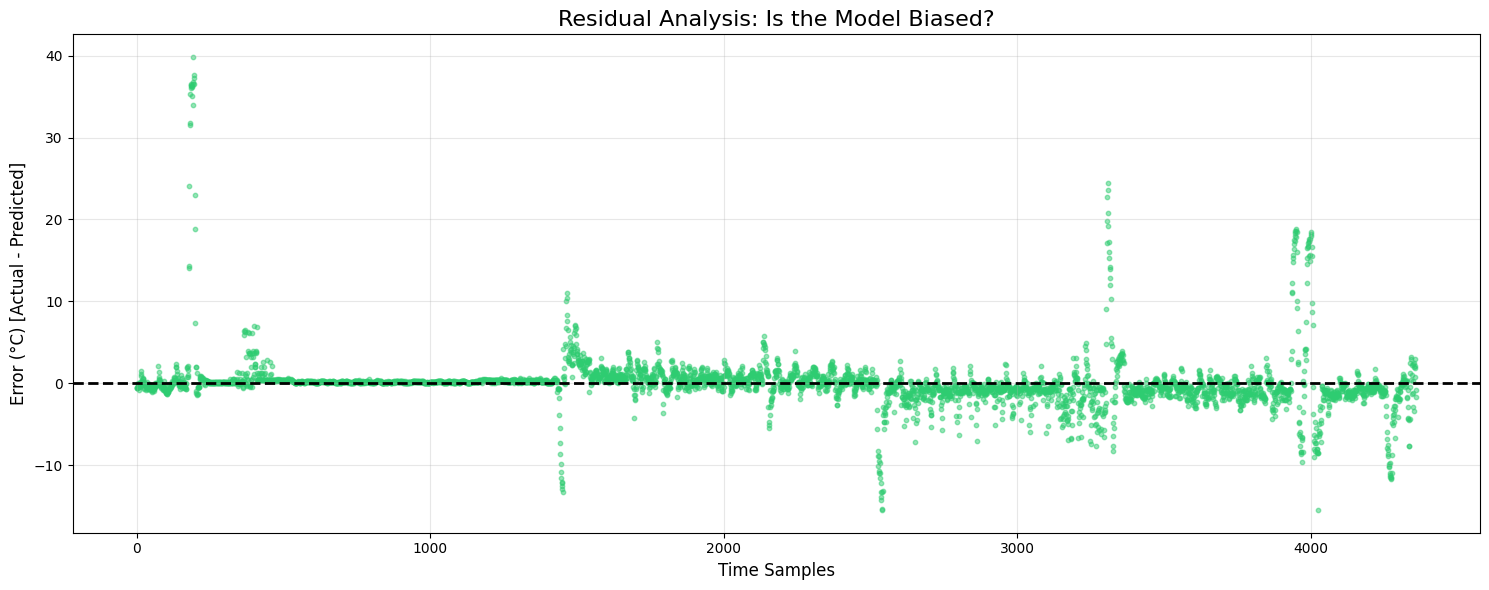

In [ ]:
import matplotlib.pyplot as plt

# Calculate Residuals (Actual - Predicted)
residuals = actual_future - final_predictions_lgb

plt.figure(figsize=(15, 6))

# Plotting the residuals over time
plt.scatter(range(len(residuals)), residuals, alpha=0.5, s=10, color='#2ecc71')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)

plt.title("Residual Analysis: Is the Model Biased?", fontsize=16)
plt.xlabel("Time Samples", fontsize=12)
plt.ylabel("Error (°C) [Actual - Predicted]", fontsize=12)
plt.grid(True, alpha=0.3)

# Add a histogram on the side to show distribution
plt.tight_layout()
plt.show()

In [ ]:
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# import numpy as np

# # --- 1. Prepare Data ---
# X = df_rf[feature_cols].values
# y = df_rf['delta_target'].values

# split = int(len(X) * 0.8)
# X_train, X_test = X[:split], X[split:]
# y_train, y_test = y[:split], y[split:]
# test_current_temps = df_rf['temp_cpu'].values[split:]

# # --- 2. Scaling (Crucial for KNN) ---
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # --- 3. Train KNN ---
# # n_neighbors=7 is a good balance between bias and variance
# knn_model = KNeighborsRegressor(n_neighbors=7)
# knn_model.fit(X_train_scaled, y_train)

# # --- 4. Predict & Reconstruct ---
# y_pred_delta_knn = knn_model.predict(X_test_scaled)
# final_predictions_knn = test_current_temps + y_pred_delta_knn
# actual_future = test_current_temps + y_test

# # Metrics
# knn_r2 = r2_score(actual_future, final_predictions_knn)
# knn_mae = mean_absolute_error(actual_future, final_predictions_knn)
# knn_rmse = np.sqrt(mean_squared_error(actual_future, final_predictions_knn))

# print(f"--- KNN Metrics ---")
# print(f"R2 Score: {knn_r2:.4f}")
# print(f"MAE:      {knn_mae:.4f} °C")
# print(f"RMSE:     {knn_rmse:.4f} °C")

--- KNN Metrics ---
R2 Score: 0.9470
MAE:      1.5532 °C
RMSE:     3.7366 °C


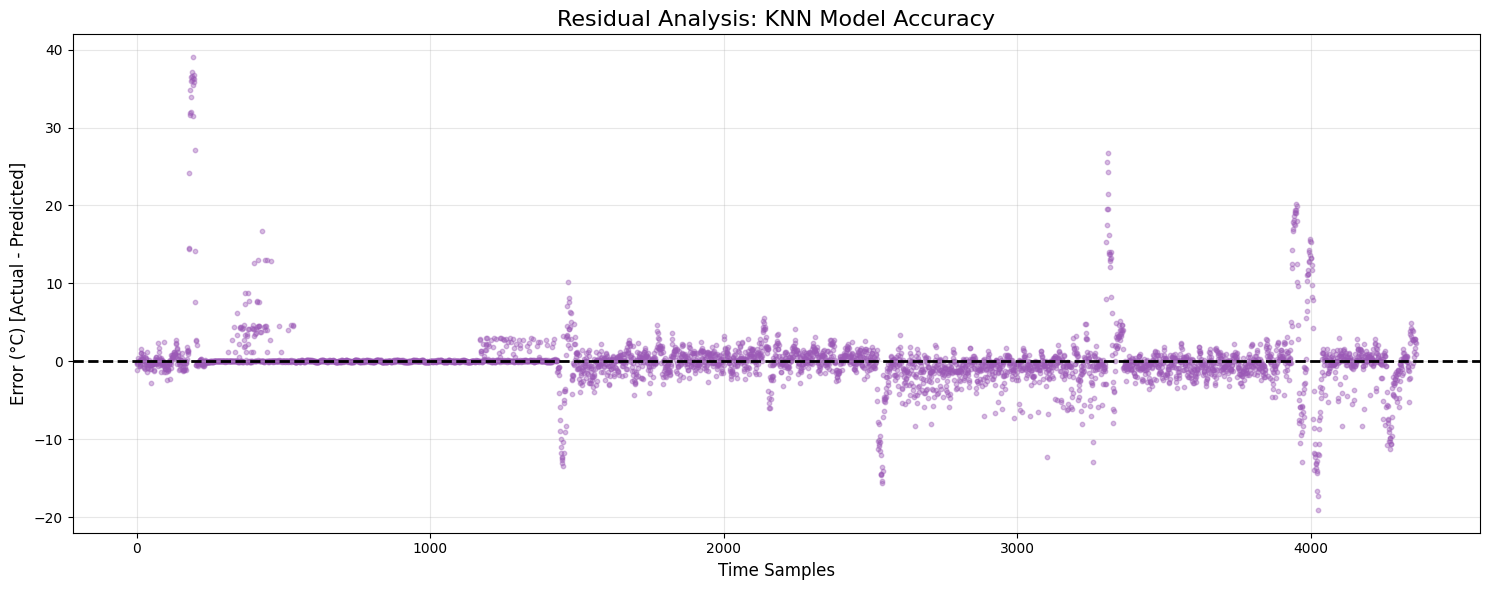

In [ ]:
# import matplotlib.pyplot as plt

# # Calculate Residuals
# residuals_knn = actual_future - final_predictions_knn

# plt.figure(figsize=(15, 6))
# plt.scatter(range(len(residuals_knn)), residuals_knn, alpha=0.4, s=10, color='#9b59b6')
# plt.axhline(y=0, color='black', linestyle='--', linewidth=2)

# plt.title("Residual Analysis: KNN Model Accuracy", fontsize=16)
# plt.xlabel("Time Samples", fontsize=12)
# plt.ylabel("Error (°C) [Actual - Predicted]", fontsize=12)
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

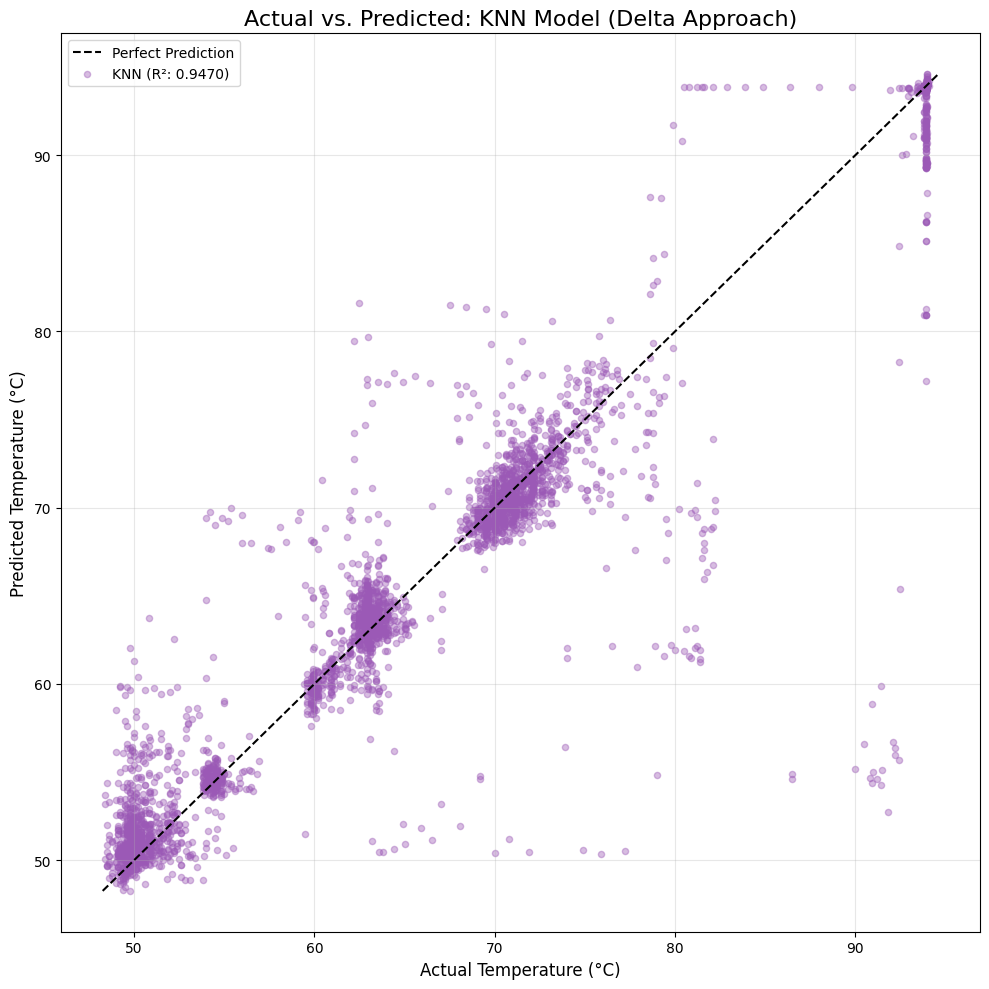

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 10))

# # 1. Plot the 45-degree Reference Line
# min_val = min(actual_future.min(), final_predictions_knn.min())
# max_val = max(actual_future.max(), final_predictions_knn.max())
# plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Perfect Prediction')

# # 2. Scatter Plot for KNN
# plt.scatter(actual_future, final_predictions_knn, alpha=0.4, s=20, color='#9b59b6', label=f'KNN (R²: {knn_r2:.4f})')

# # 3. Styling
# plt.title("Actual vs. Predicted: KNN Model (Delta Approach)", fontsize=16)
# plt.xlabel("Actual Temperature (°C)", fontsize=12)
# plt.ylabel("Predicted Temperature (°C)", fontsize=12)
# plt.legend(loc='upper left')
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# **REGRESSION MODEL**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# --- 1. Train Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# --- 2. Predict & Reconstruct ---
y_pred_delta_lr = lr_model.predict(X_test)
final_predictions_lr = test_current_temps + y_pred_delta_lr
actual_future = test_current_temps + y_test

# --- 3. Metrics ---
lr_r2 = r2_score(actual_future, final_predictions_lr)
lr_mae = mean_absolute_error(actual_future, final_predictions_lr)
lr_rmse = np.sqrt(mean_squared_error(actual_future, final_predictions_lr))

print(f"--- Linear Regression Metrics ---")
print(f"R2 Score: {lr_r2:.4f}")
print(f"MAE:      {lr_mae:.4f} °C")
print(f"RMSE:     {lr_rmse:.4f} °C")

--- Linear Regression Metrics ---
R2 Score: 0.9519
MAE:      1.4919 °C
RMSE:     3.5623 °C


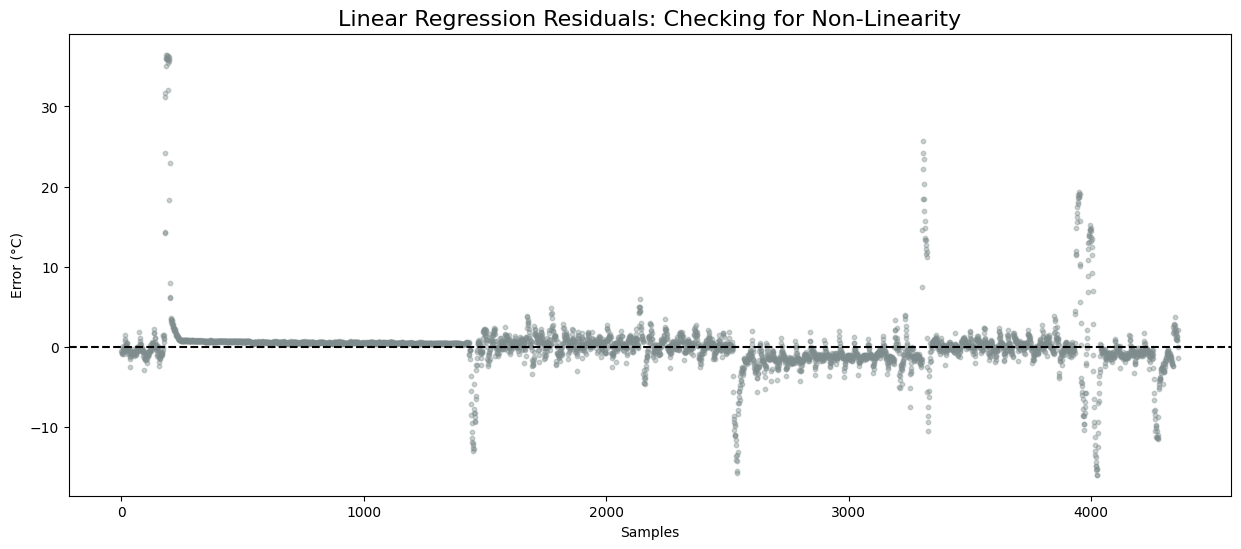

In [ ]:
import matplotlib.pyplot as plt

# Calculate Residuals
res_lr = actual_future - final_predictions_lr

plt.figure(figsize=(15, 6))
plt.scatter(range(len(res_lr)), res_lr, alpha=0.4, s=10, color='#7f8c8d')
plt.axhline(y=0, color='black', linestyle='--')

plt.title("Linear Regression Residuals: Checking for Non-Linearity", fontsize=16)
plt.ylabel("Error (°C)")
plt.xlabel("Samples")
plt.show()

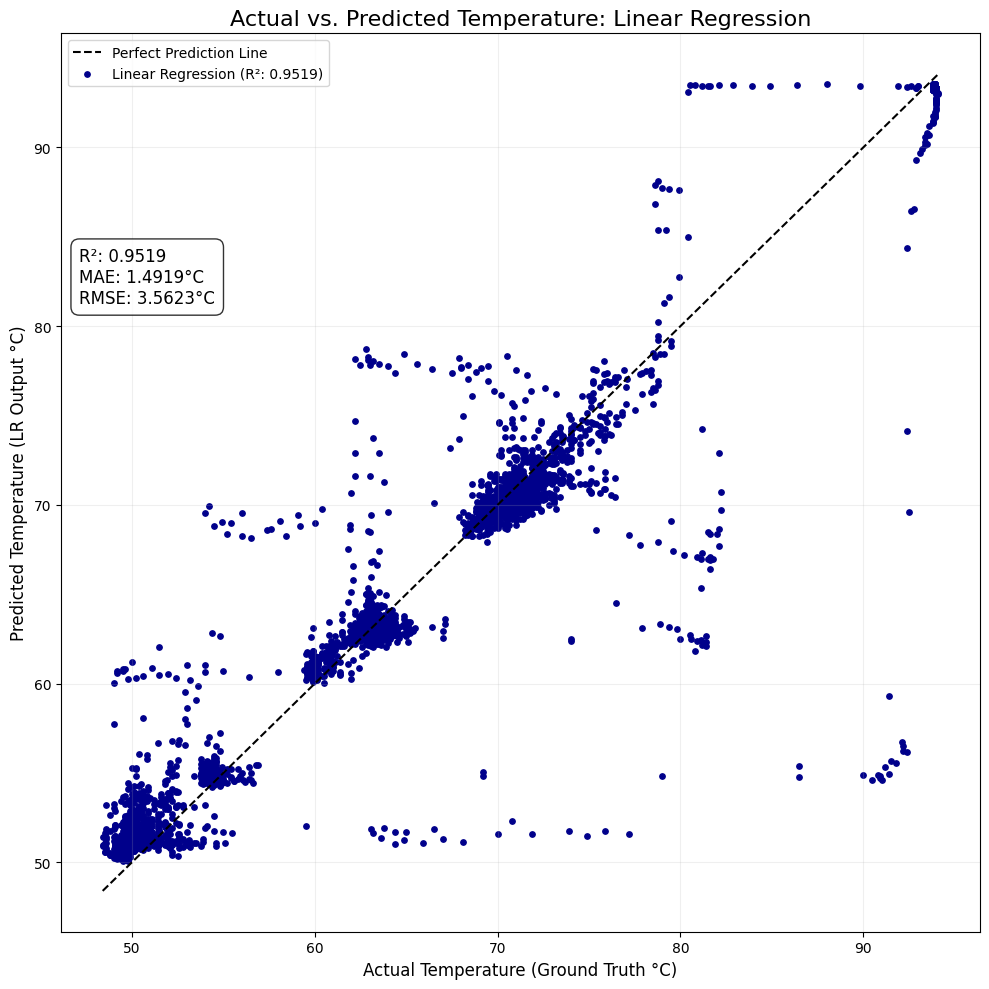

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create the figure
plt.figure(figsize=(10, 10))

# 2. Define the 'Perfect Prediction' line (45-degree diagonal)
# We calculate the min/max based on the actual data to ensure the line fits perfectly
min_val = min(actual_future.min(), final_predictions_lr.min())
max_val = max(actual_future.max(), final_predictions_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Perfect Prediction Line')

# 3. Plot the Linear Regression results
# We use a distinct color (e.g., Grey or Slate) to differentiate from your Boosting models
plt.scatter(actual_future, final_predictions_lr, s=15,
            label=f'Linear Regression (R²: {lr_r2:.4f})', color='darkblue')

# 4. Adding labels and styling for your report
plt.title("Actual vs. Predicted Temperature: Linear Regression", fontsize=16)
plt.xlabel("Actual Temperature (Ground Truth °C)", fontsize=12)
plt.ylabel("Predicted Temperature (LR Output °C)", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)

# Add a text box with the key metrics
stats_text = f'R²: {lr_r2:.4f}\nMAE: {lr_mae:.4f}°C\nRMSE: {lr_rmse:.4f}°C'
plt.gca().annotate(stats_text, xy=(0.02, 0.7), xycoords='axes fraction',
            bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.8),
            fontsize=12)

plt.tight_layout()
plt.show()

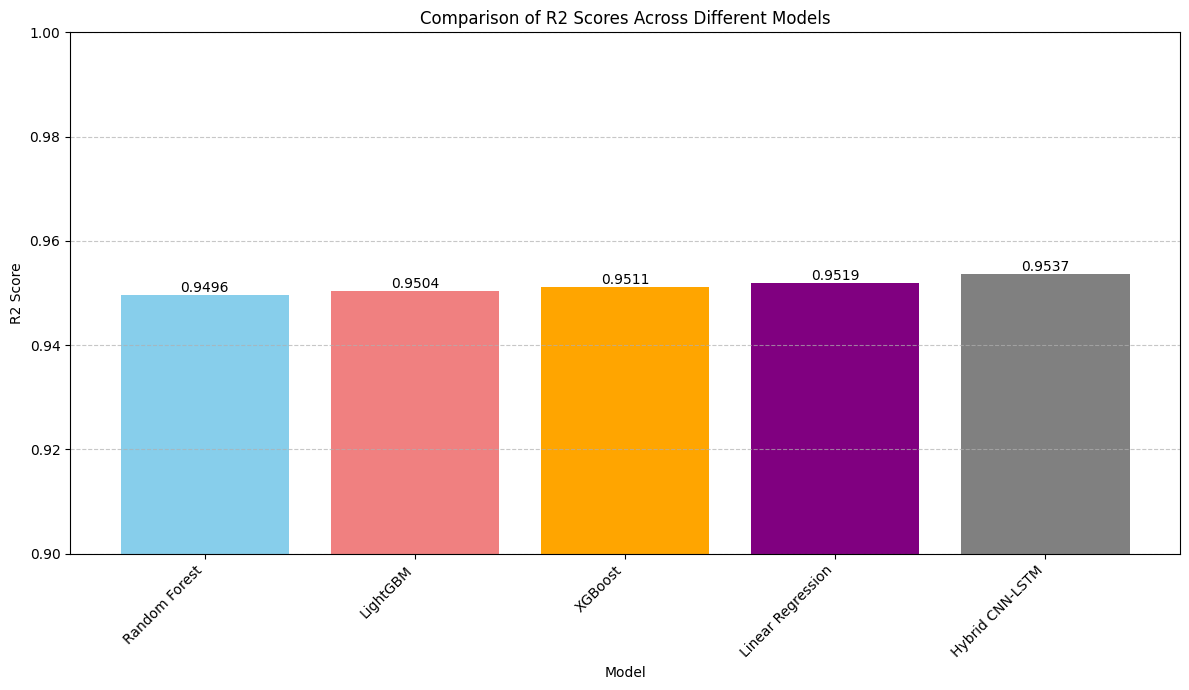

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Gather R2 scores for each model
r2_scores = {
    'Hybrid CNN-LSTM': r2,
    'Random Forest': rf_r2,
    'XGBoost': xgb_r2,
    'LightGBM': lgb_r2,
    # 'KNN': knn_r2,
    'Linear Regression': lr_r2
}

# Create a DataFrame for easy plotting
r2_df = pd.DataFrame(list(r2_scores.items()), columns=['Model', 'R2_Score'])

# Sort for better visualization
r2_df = r2_df.sort_values(by='R2_Score', ascending=True)

# Create the bar plot
plt.figure(figsize=(12, 7))
plt.bar(r2_df['Model'], r2_df['R2_Score'], color=['skyblue', 'lightcoral', 'orange', 'purple', 'grey'])
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.title('Comparison of R2 Scores Across Different Models')
plt.ylim(0.9, 1.0) # Focus on the relevant range of R2 scores
for index, row in r2_df.iterrows():
    plt.text(row['Model'], row.R2_Score, f'{row.R2_Score:.4f}', color='black', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()